In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
from contra_seq_dataset import get_dataset_array, get_anc_map
import copy

home = '/home/kat/Repos/SALSA/'
anc_path = f'{home}data/model_ready/01/test/anchor_smiles.csv'
aug_path = f'{home}data/model_ready/01/test/augmented_smiles.csv'

ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
df = copy.deepcopy(ds_arr)
df_sort = df.sort_values(by='smiles', key=lambda x: x.str.len())
# display(df_sort)

In [3]:
df_ancs = df_sort[df_sort.atype=='Anc'][:3]
df_ancs

,smiles,atype,anc_idx
1909,COCOCCC#CCO,Anc,1909
449,CSCCCCCCN=C=S,Anc,449
314,Nc1cccc2nnccc12,Anc,314


In [4]:
# from rdkit import Chem
# from rdkit.Chem.Draw import IPythonConsole
# from rdkit.Chem import Draw
# import matplotlib.pyplot as plt

# for i in df_ancs.anc_idx.values:
    
#     smis = df[df.anc_idx==i]
#     anc = smis[smis.atype=='Anc'].smiles.values[0]
#     augs = smis[smis.atype=='Aug'].smiles.values
    
#     mols = [Chem.MolFromSmiles(anc)] + [Chem.MolFromSmiles(sm) for sm in augs]
#     img = Draw.MolsToGridImage(mols,molsPerRow=6, subImgSize=(250, 250))
#     display(img)

In [5]:
def view_difference(mol1, mol2):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match1 = mol1.GetSubstructMatch(mcs_mol)
    target_atm1 = []
    for atom in mol1.GetAtoms():
        if atom.GetIdx() not in match1:
            target_atm1.append(atom.GetIdx())
    match2 = mol2.GetSubstructMatch(mcs_mol)
    target_atm2 = []
    for atom in mol2.GetAtoms():
        if atom.GetIdx() not in match2:
            target_atm2.append(atom.GetIdx())
    return Draw.MolsToGridImage([mol1, mol2],highlightAtomLists=[target_atm1, target_atm2])

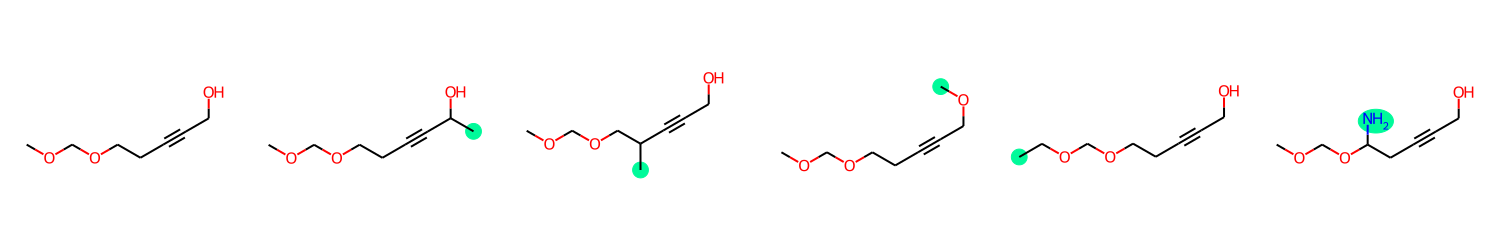

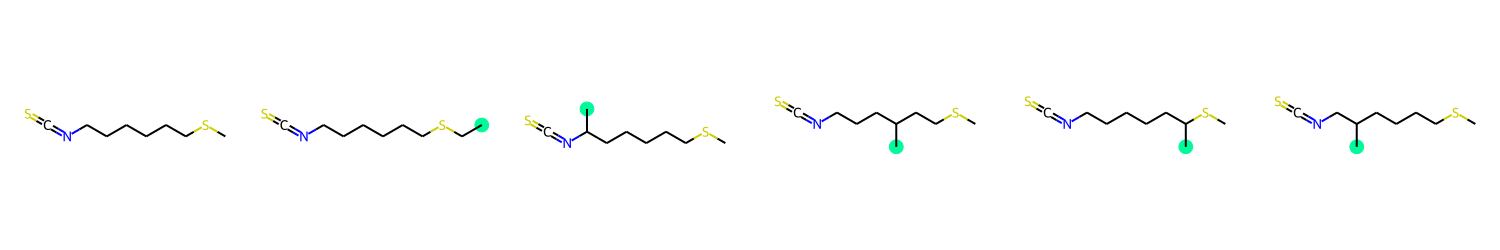

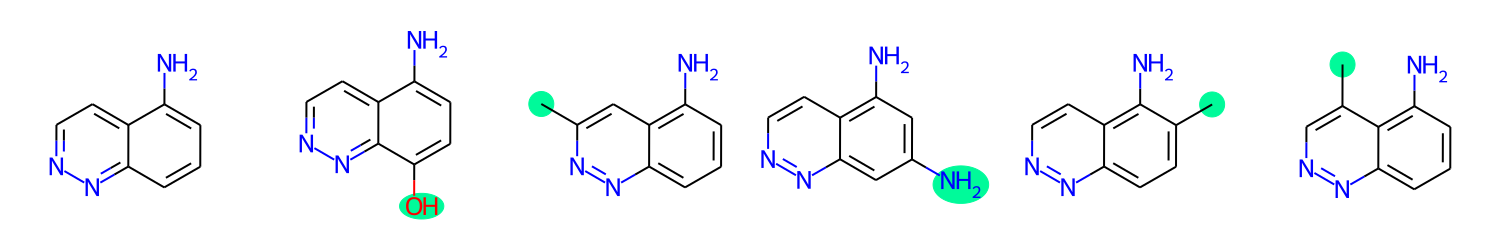

In [6]:
from rdkit.Chem import AllChem
from rdkit import Chem, Geometry
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True)
# IPythonConsole.drawOptions.minFontSize=20
from matplotlib.colors import ColorConverter

def get_highlighted_atoms(anc_mol, aug_mol):
    mcs = rdFMCS.FindMCS([anc_mol,aug_mol])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match = aug_mol.GetSubstructMatch(mcs_mol)
    highlight_atoms = []
    for atom in aug_mol.GetAtoms():
        if atom.GetIdx() not in match:
            highlight_atoms.append(atom.GetIdx())
    return highlight_atoms


c = ColorConverter().to_rgb('mediumspringgreen') #('mediumspringgreen') #('cyan')

for idx in df_ancs.anc_idx.values:
    smis = df[df.anc_idx==idx]
    anc_smi = smis[smis.atype=='Anc'].smiles.values[0]
    aug_smis = smis[smis.atype=='Aug'].smiles.values
    
    anc_mol = Chem.MolFromSmiles(anc_smi)
    aug_mols = [Chem.MolFromSmiles(sm) for sm in aug_smis] 
    all_mols = [anc_mol] + aug_mols
    
    matched_coords = [x.GetSubstructMatch(anc_mol) for x in all_mols]
    
    AllChem.Compute2DCoords(anc_mol)
    coords = [anc_mol.GetConformer().GetAtomPosition(x) for x in matched_coords[0]]
    coords2D = [Geometry.Point2D(pt.x,pt.y) for pt in coords]
    
    highlights = []
    colors = []
    
    for i,mol in enumerate(all_mols):
                
        # align skeletons
        coordDict={}
        for j,coord in enumerate(coords2D):
            coordDict[matched_coords[i][j]] = coord
        AllChem.Compute2DCoords(mol,coordMap=coordDict)
        
        # get highlights for aug mols
        if i == 0:
            highlight = False
            atom_col = {}
        else:
            highlight = get_highlighted_atoms(anc_mol, mol)
            atom_col = {highlight[0]: c}
            
        colors.append(atom_col)
        highlights.append(highlight)
    
    img = Draw.MolsToGridImage(all_mols, molsPerRow=6, highlightAtomLists=highlights,
                               highlightAtomColors=colors, subImgSize=(250, 250))
    display(img)

In [7]:
# anc = Chem.MolFromSmiles('COCOCCC#CCO')
# aug = Chem.MolFromSmiles('COCOCCC#CC(C)O')
# get_highlighted_atoms(anc, aug)

# from matplotlib.colors import ColorConverter
# img = Draw.MolToImage(aug, highlightAtoms=[1,2], highlightColor=ColorConverter().to_rgb('aqua'))
# img

In [8]:
# from PIL import Image
# from rdkit.Chem import AllChem
# from rdkit import Chem,Geometry
# from rdkit.Chem.Draw import IPythonConsole
# from rdkit.Chem import Draw
# import matplotlib.pyplot as plt

# all_imgs = []
# for idx in df_ancs.anc_idx.values:
#     smis = df[df.anc_idx==idx]
#     anc = smis[smis.atype=='Anc'].smiles.values[0]
#     augs = smis[smis.atype=='Aug'].smiles.values
    
#     anc_mol = Chem.MolFromSmiles(anc)
#     all_mols = [anc_mol] + [Chem.MolFromSmiles(sm) for sm in augs] 
#     matched_coords = [x.GetSubstructMatch(anc_mol) for x in all_mols]
    
#     AllChem.Compute2DCoords(anc_mol)
#     coords = [anc_mol.GetConformer().GetAtomPosition(x) for x in matched_coords[0]]
#     coords2D = [Geometry.Point2D(pt.x,pt.y) for pt in coords]
    
#     for i,mol in enumerate(all_mols):
#         coordDict={}
#         for j,coord in enumerate(coords2D):
#             coordDict[matched_coords[i][j]] = coord
#         AllChem.Compute2DCoords(mol,coordMap=coordDict)

#     imgs = [Draw.MolToImage(x,size=(100,100)) for x in all_mols]
#     all_imgs.append(imgs)
    
# img = Image.new('RGBA',(600,300)) 
# for i in range(3): 
#     for j in range(6):
#         img.paste(all_imgs[i][j],(100*j,100*i))
# display(img)

In [9]:
# i=1909
# smis = df[df.anc_idx==i]
# anc = smis[smis.atype=='Anc'].smiles.values[0]
# augs = smis[smis.atype=='Aug'].smiles.values

# template = Chem.MolFromSmiles(anc)
# AllChem.Compute2DCoords(template)

# mols = [template] + [Chem.MolFromSmiles(sm) for sm in augs]

# for m in mols:
#     _ = AllChem.GenerateDepictionMatching2DStructure(m,template)

In [10]:
# from rdkit.Chem import AllChem
# from rdkit import Chem
# from rdkit.Chem.Draw import IPythonConsole
# from rdkit.Chem import Draw
# import matplotlib.pyplot as plt

# for i in df_ancs.anc_idx.values:
    
#     smis = df[df.anc_idx==i]
#     anc = smis[smis.atype=='Anc'].smiles.values[0]
#     augs = smis[smis.atype=='Aug'].smiles.values
    
#     template = Chem.MolFromSmiles(anc)
#     AllChem.Compute2DCoords(template)
    
#     mols = [template] + [Chem.MolFromSmiles(sm) for sm in augs]
    
#     for m in mols:
#         _ = AllChem.GenerateDepictionMatching2DStructure(m,template)
        
#     print(i)
    
    
# #     img = Draw.MolsToGridImage(mols,molsPerRow=6, subImgSize=(250, 250))
#     display(img)

In [11]:
# from rdkit import Chem
# from rdkit.Chem.Draw import IPythonConsole
# from rdkit.Chem import Draw
# import matplotlib.pyplot as plt

# for i in df_ancs.anc_idx.values:
    
#     smis = df[df.anc_idx==i]
#     anc = smis[smis.atype=='Anc'].smiles.values[0]
#     augs = smis[smis.atype=='Aug'].smiles.values
    
#     mols = [Chem.MolFromSmiles(anc)] + [Chem.MolFromSmiles(sm) for sm in augs]
#     img = Draw.MolsToGridImage(mols,molsPerRow=6, subImgSize=(250, 250))
#     display(img)